<a href="https://colab.research.google.com/github/danamelissamendoza/Talleres-del-curso-IA-aplicada-a-la-economia/blob/main/3_Taller_PCA_Mendoza_Vasquez_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/4_Aprendizaje_no_supervisado/3_Taller_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller: Creación de un Índice de Clima de Inversión con Análisis de Componentes Principales (PCA)**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

- Dana Melissa Mendoza Santiago
- Manuela Vásquez Osorio
-

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma:“Taller_PCA_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/q1ZSe3N80C.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

28 de abril de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

### Contexto

**Escenario:** Eres un científico de datos recién contratado como consultor experto por el **Ministerio de Comercio, Industria y Turismo (MinCIT)** de Colombia. Tu tarea principal es crear un **'Índice de Clima para la Inversión'** cuantitativo que permita clasificar y comparar el entorno competitivo de los países de América Latina y el Caribe. Este índice orientará las estrategias de integración regional y las políticas para atraer Inversión Extranjera Directa (IED).

**Objetivo:** Utilizando la base de datos de indicadores provista (preparada para este análisis) y la técnica de **Análisis de Componentes Principales (PCA)**, deberás extraer la "variable latente" que resume el clima de inversión, interpretar sus pesos económicos y presentar un ranking de países con recomendaciones ejecutivas.


## Ejercicio 1: Configuración Inicial, Carga y Exploración de Datos

1.1 Importa las librerías necesarias

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [17]:
# Configuraciones de visualización
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

1.2 Carga el dataset "Indicators.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_indicators".

In [18]:
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/4_Aprendizaje_no_supervisado/Indicators.csv'
df_indicators = pd.read_csv(ruta)

df_indicators.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,CountryCode,IndicatorCode,Year,Value
0,CHL,NV.AGR.TOTL.ZS,2014,6.75
1,CHL,NE.TRD.GNFS.ZS,2014,74.31
2,CHL,NY.GDP.MKTP.KD.ZG,2014,7.65
3,CHL,FP.CPI.TOTL.ZG,2014,12.62
4,CHL,GC.DOD.TOTL.GD.ZS,2014,42.83


In [19]:
# Debe ser (121, 4)
print("Dimensiones del DataFrame Indicators:")
print(df_indicators.shape)

Dimensiones del DataFrame Indicators:
(121, 4)


In [20]:
print("\nInformación general del DataFrame:")
df_indicators.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CountryCode    121 non-null    object 
 1   IndicatorCode  121 non-null    object 
 2   Year           121 non-null    int64  
 3   Value          121 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.9+ KB


1.3 Carga el dataset "Country.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_countries".

In [21]:
ruta = '/content/drive/MyDrive/4_Aprendizaje_no_supervisado/Country.csv'
df_countries = pd.read_csv(ruta)

print(df_countries.head())

  CountryCode   ShortName                     Region
0         CHL       Chile  Latin America & Caribbean
1         PAN      Panamá  Latin America & Caribbean
2         CRI  Costa Rica  Latin America & Caribbean
3         COL    Colombia  Latin America & Caribbean
4         PER        Perú  Latin America & Caribbean


In [22]:
# Debe ser (14, 3)
print("Dimensiones del DataFrame Countries:")
print(df_countries.shape)

Dimensiones del DataFrame Countries:
(14, 3)


In [23]:
print("\nInformación general del DataFrame:")
df_countries.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CountryCode  14 non-null     object
 1   ShortName    14 non-null     object
 2   Region       14 non-null     object
dtypes: object(3)
memory usage: 468.0+ bytes


### Ejercicio 2: Selección y Preparación de Datos

Para el análisis del MinCIT, hemos preseleccionado un conjunto de variables clave.

2.1. Utiliza el diccionario para modificar los códigos de los indicadores por sus descripciones

In [24]:
nombre_indicadores = {
    'NV.AGR.TOTL.ZS': 'Agricultura (% del PIB)',
    'NE.TRD.GNFS.ZS': 'Comercio (% del PIB)',
    'NY.GDP.MKTP.KD.ZG': 'Crecimiento del PIB (%)',
    'FP.CPI.TOTL.ZG': 'Inflación (%)',
    'GC.DOD.TOTL.GD.ZS': 'Deuda del gob. central (% del PIB)',
    'SE.XPD.TOTL.GD.ZS': 'Gasto en educación (% del PIB)',
    'SH.XPD.CHEX.GD.ZS': 'Gasto en salud (% del PIB)',
    'IQ.CPA.BREG.XQ': 'Facilidad para hacer negocios',
    'IC.LGL.DURS': 'Días para cumplir contratos',
    'TX.VAL.MRCH.XD.WD': 'Exportaciones (US$)',
    'TM.VAL.MRCH.XD.WD': 'Importaciones (US$)'
}

In [25]:
df_indicators['IndicatorCode'] = df_indicators['IndicatorCode'].replace(nombre_indicadores)
df_indicators.head()

,CountryCode,IndicatorCode,Year,Value
0,CHL,Agricultura (% del PIB),2014,6.75
1,CHL,Comercio (% del PIB),2014,74.31
2,CHL,Crecimiento del PIB (%),2014,7.65
3,CHL,Inflación (%),2014,12.62
4,CHL,Deuda del gob. central (% del PIB),2014,42.83


2.2. Utiliza pivot table para crear un nuevo dataframe donde se encuentren los países como filas y los indicadores como columnas. Llama a este dataframe "df_pivot". No olvides colocar .reset_index() para que la columna de código de países quede como una columna y no como el índice.

In [26]:
df_pivot = df_indicators.pivot_table(index=['CountryCode', 'Year'], columns='IndicatorCode', values='Value').reset_index()
df_pivot.head()

IndicatorCode,CountryCode,Year,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
0,ARG,2014,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28
1,BOL,2014,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05
2,BRA,2014,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60
3,CHL,2014,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
4,COL,2014,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61


2.3. Crea el dataframe "df_final", realizando un merge entre "df_pivot" y "df_countries" con el fin de agregar el nombre de los países.

In [27]:
df_final = pd.merge(df_pivot, df_countries, on='CountryCode')
df_final.head()


,CountryCode,Year,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),ShortName,Region
0,ARG,2014,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28,Argentina,Latin America & Caribbean
1,BOL,2014,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05,Bolivia,Latin America & Caribbean
2,BRA,2014,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60,Brasil,Latin America & Caribbean
3,CHL,2014,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,Chile,Latin America & Caribbean
4,COL,2014,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61,Colombia,Latin America & Caribbean


2.4. Elimina las columnas "Region" y "CountryCode" y establece la columna 'ShortName' como el índice del dataframe

In [28]:
df_final = df_final.drop(columns=['Region', 'CountryCode'], errors='ignore')
if df_final.index.name == 'ShortName':
    df_final = df_final.reset_index()

df_final = df_final.set_index('ShortName')
df_final.head()

,Year,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
ShortName,,,,,,,,,,,,
Argentina,2014,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28
Bolivia,2014,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05
Brasil,2014,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60
Chile,2014,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
Colombia,2014,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61


### Ejercicio 3: Limpieza de Datos (Imputación de Valores Faltantes)

En la vida real de un economista, los datos tienen huecos. El PCA requiere bases completas. Usaremos una estrategia de imputación por la media para resolver los NaN.

3.1. Revisa cuántos valores faltantes hay en cada columna

In [29]:
df_final.isnull().sum()

,0
Year,0
Agricultura (% del PIB),4
Comercio (% del PIB),3
Crecimiento del PIB (%),0
Deuda del gob. central (% del PIB),4
Días para cumplir contratos,2
Exportaciones (US$),3
Facilidad para hacer negocios,5
Gasto en educación (% del PIB),3
Gasto en salud (% del PIB),4


3.2. Para cada columna, utiliza el promedio del resto de países de Latinoamérica para imputar los valores faltantes. El resultado debe quedar en un dataframe llamado "df_final_imputed". Al final revisa que no haya quedado ningún valor faltante en las columnas del dataframe.

In [30]:
df_final_imputed = df_final.copy()
for col in df_final_imputed.columns:
    if col not in ['CountryCode', 'Year']:

        df_final_imputed[col] = df_final_imputed.groupby('Year')[col].transform(
            lambda x: x.fillna(x.mean())
        )
df_final_imputed.isna().sum()


,0
Year,0
Agricultura (% del PIB),0
Comercio (% del PIB),0
Crecimiento del PIB (%),0
Deuda del gob. central (% del PIB),0
Días para cumplir contratos,0
Exportaciones (US$),0
Facilidad para hacer negocios,0
Gasto en educación (% del PIB),0
Gasto en salud (% del PIB),0


### Ejercicio 4: Matriz de Correlaciones y Estandarización de Variables

4.1. Grafica un mapa de calor para ver las correlaciones entre las variables.

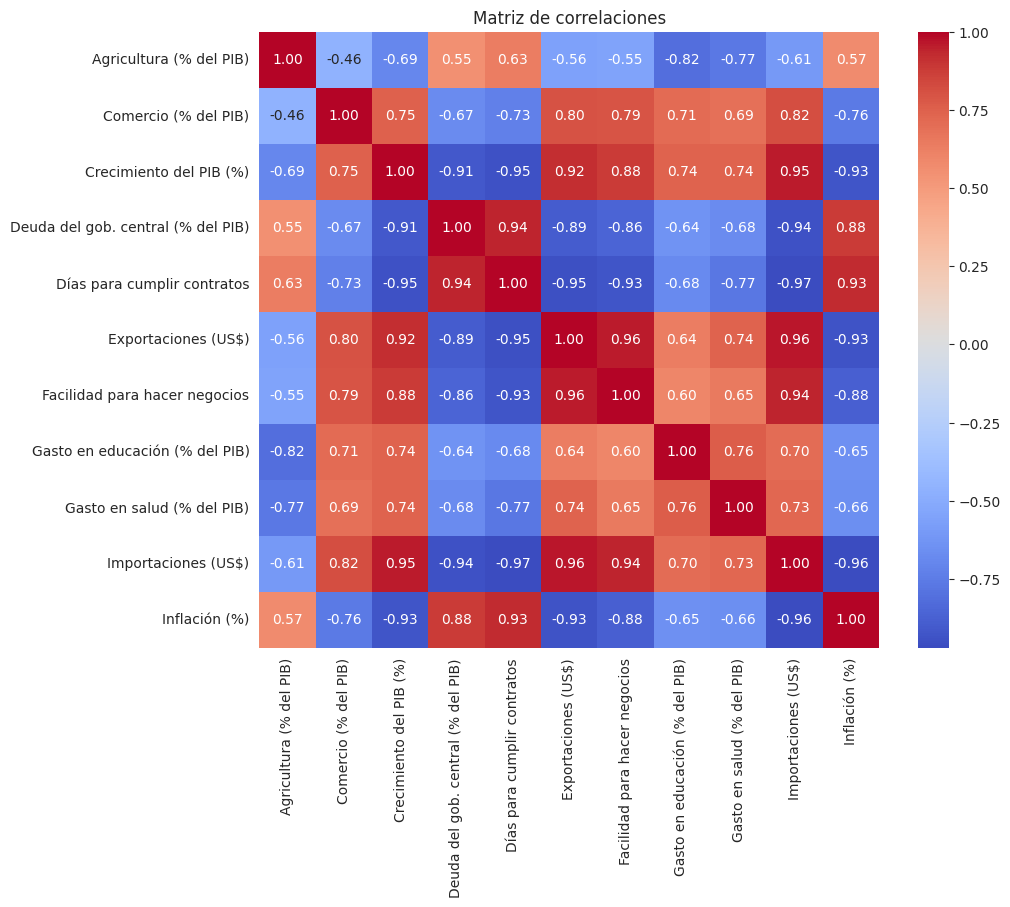

In [31]:
df_numeric = df_final_imputed.drop(columns=['Year'])

corr = df_numeric.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlaciones')
plt.show()

4.2. Interpreta los resultados resaltando las correlaciones más relevantes.

La matriz de correlación nos da una idea de que tan relacionadas están las variables que estamos analizando. En términos generales hay un patrón claro en el que el crecimiento del PIB está fuertemente asociado de manera positiva con variables como las exportaciones, importaciones, facilidad para hacer negocios y el comercio; esto significa que las economías que crecen más estás más abiertas al comercio internacional, también que tienen mejores condiciones institucionales y de mercado.

Por otro lado, se observa que el crecimiento tiene relaciones negativas fuertes con la inflación, deuda pública y los días para cumplir contratos. Esto indica que economías con mayor crecimiento suelen tener menor inflación, menor carga de deuda y sistemas más eficientes en términos institucionales.

También se puede identificar que variables como exportaciones, importaciones, comercio como porcentaje del PIB y facilidad para hacer encogidos están altamente correlacionados entre sí, lo que refuerza la idea de que la apertura económica y un buen entorno empresarial van de la mano.

Finalmente, variables como inflación, deuda pública, días para cumplir contratos y la participación de la agricultura en el PIB tienden a moverse juntas y en sentido contrario al crecimiento, lo que sugiere que las economías más rezagadas estructuralmente presentan mayores desequilibrios macroeconómicos e institucionales.

4.3. Las exportaciones están en miles de millones de dólares y el crecimiento en porcentajes de un dígito. PCA busca varianzas, por lo que estandarizar (Media 0, Desviación 1) es un paso matemático obligatorio para no sesgar el modelo hacia las variables nominales grandes.  Estandariza todas las variables del dataframe y almacena el resultado en X_scaled.

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

### Ejercicio 5: Aplicación de PCA

Vamos a correr PCA para identificar el número de componentes. Buscamos capturar la mayor cantidad de información (varianza) con la menor cantidad de dimensiones.

5.1. Corre PCA sobre X_scaled y calcula la varianza acumulada. Almacénala en la variable "varianza_acumulada".

In [33]:
pca = PCA()
pca.fit(X_scaled)
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

5.2. Similar a como lo vimos en clase, grafica la varianza explicada acumulada por componente.

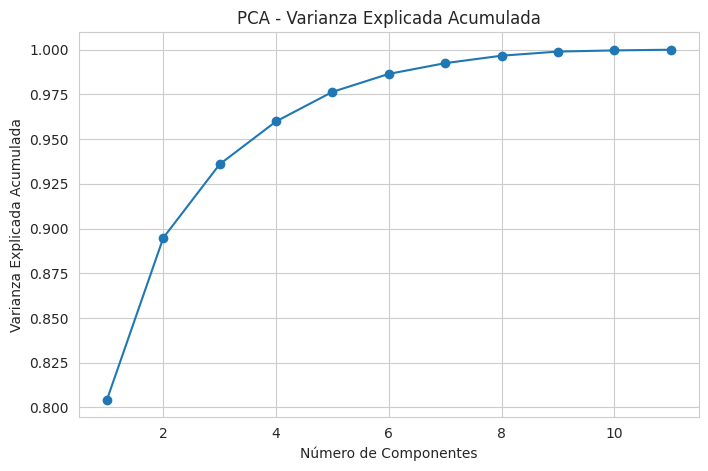

In [34]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, marker='o')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('PCA - Varianza Explicada Acumulada')
plt.grid(True)
plt.show()

5.3. Realiza un análisis del gráfico anterior.

incrementa el número de componentes en el PCA, la gráfica nos permite identificar cuántos componentes son necesarios para capturar la mayor parte de información original con la menor cantidad de dimensiones posible.

Podemos ver que con un solo componente ya se captura aproximadamente el 80% de la varianza, lo cual es bastante alto. Al pasar a dos componentes la varianza explicada aumenta cerca del 90%. Con tres y cuatro componentes, la varianza acumulada alcanza aproximadamente entre el 94 y 96%, lo que indica que se obtiene una ganancia importante al añadir estas dimensiones.

Ahora bien, a partir del quinto componente, la curva comienza a aplanarse, alcanzando alrededor del 98% de varianza explicada. Desde este punto en adelante, añadir más componentes apenas incrementa la varianza en fracciones más pequeñas, acercándose lentamente al 100%, lo que indica que las contribuciones adicionales son marginales.

En este caso, el punto de codo, donde la mejora deja de ser significativa, se encuentra aproximadamente entre los componentes 4 y 5, por lo que una elección razonable sería utilizar este número de componentes, ya que permiten conservar la mayor parte de la información reduciendo considerablemente la dimensionalidad del conjunto de datos.

### Ejercicio 6: Interpretación Económica de los Componentes (Loadings)

Nos vamos a quedar con un solo componente. Vamor a analizar qué variables originales alimentan a este componente.

6.1. Corre nuevamente el PCA, pero ahora indicando que tenga en cuenta solo 1 componente. Almacena el modelo en "pca_final" y los resultados en "X_pca".

In [35]:
pca_final = PCA(n_components=1)
X_pca = pca_final.fit_transform(X_scaled)

6.2. Grafica el mapa de calor de los loadings como lo vimos en clase

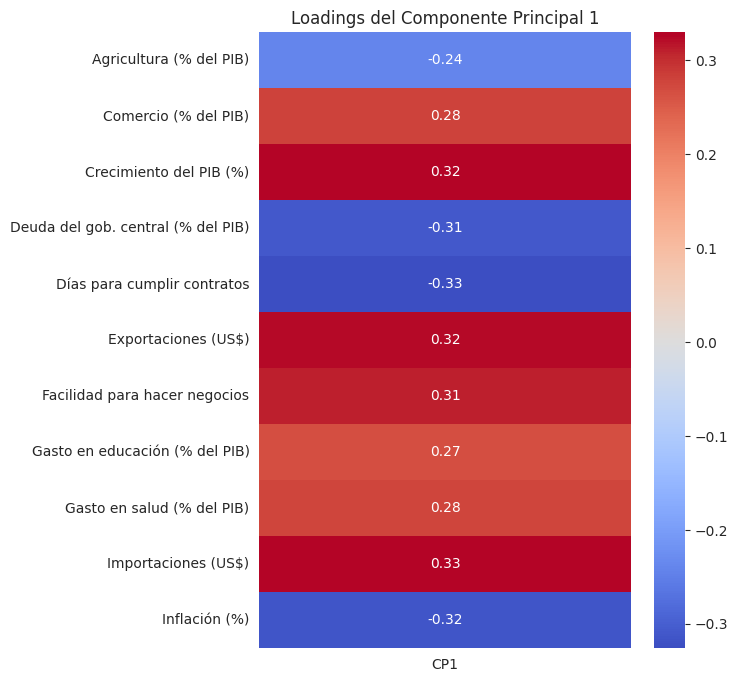

In [36]:
loadings = pd.DataFrame(
    pca_final.components_.T,
    index=df_numeric.columns,
    columns=['CP1']
)

plt.figure(figsize=(6,8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)
plt.title('Loadings del Componente Principal 1')
plt.show()

6.3. Realiza una interpretación de los loadings. ¿Cuáles variables tienen las cargas altas y positivas y cuáles las cargas altas y negativas? De acuerdo con este análisis, ¿consideras que efectivamente podemos utilizar el componente 1 como un índice del clima para la inversión en cada país de Latinoamérica? ¿por qué si o por qué no?

1. **Variables con Cargas Altas y Positivas**
Estas variables se mueven en la misma dirección que el CP1, esto quiere decir que un aumento en estas métricas incrementa el valor del componente. Estas variables suelen estar asociadas a dinamismo económico, apertura comercial y desarrollo de capital humano.

Importaciones (US$): 0.33

Crecimiento del PIB (%): 0.32

Exportaciones (US$): 0.32

Facilidad para hacer negocios: 0.31

Gasto en salud y educación: 0.28 y 0.27 respectivamente.


2. **Variables con Cargas Altas y Negativas**
Estas variables tienen una relación inversa con el CP1. Si estos valores suben, el valor del componente baja. Estas métricas representan barreras institucionales, inestabilidad macroeconómica y una estructura económica menos industrializada/tecnificada (alta dependencia agrícola).

Días para cumplir contratos: -0.33

Inflación (%): -0.32

Deuda del gob. central (% del PIB): -0.31

Agricultura (% del PIB): -0.24

3. **¿Puede el CP1 ser un "Índice de Clima para la Inversión"?**

Sí, dadas las siguien tes razones:

*   El hecho de que la "Facilidad para hacer negocios" sea positiva y los "Días para cumplir contratos" sea fuertemente negativa sugiere que el componente captura la eficiencia del entorno legal y regulatorio. Para un inversor, menos burocracia y rapidez judicial son claves.

*   Al incluir exportaciones e importaciones con cargas altas, el índice refleja qué tan integrada está la economía al mundo y qué tan rápido está creciendo el mercado interno (PIB).

*   El componente penaliza la inflación alta y el endeudamiento excesivo, ambos factores de riesgo que ahuyentan la inversión extranjera.

*   El CP1 nos muestra un panorama en cuanto a la salud económica y la facilidad operativa de los países. Un país con un CP1 alto sería percibido como un destino con clima de inversión favorable (crecimiento, apertura, baja inflación y eficiencia legal), mientras que un CP1 bajo indicaría un entorno de alto riesgo o estancamiento.













### Ejercicio 7: Creación del 'Índice de Clima para la Inversión'

Asignaremos el CP1 como nuestro 'Índice de Clima para la Inversión' y construiremos el ranking regional.

In [37]:
df_final['Indice_Inversion'] = X_pca[:, 0]
df_final.head()

,Year,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),Indice_Inversion
ShortName,,,,,,,,,,,,,
Argentina,2014,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28,-5.93
Bolivia,2014,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05,-1.93
Brasil,2014,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60,-1.24
Chile,2014,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,4.89
Colombia,2014,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61,2.13


7.1. Ordena el df_final por el índice de clima para la inversión de mayor a menor valor del índice.

In [38]:
df_final.sort_values(by='Indice_Inversion', ascending=False)


,Year,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),Indice_Inversion
ShortName,,,,,,,,,,,,,
Chile,2014,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,4.89
Panamá,2014,5.80,NaN,6.89,43.42,555.93,"83,978,447,805.32",5.40,5.95,7.72,"76,338,244,613.60",8.11,3.89
Costa Rica,2014,8.11,70.86,5.88,NaN,610.31,"78,236,959,844.64",5.53,5.64,6.77,"72,324,083,969.39",8.49,2.75
Colombia,2014,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61,2.13
Uruguay,2014,8.21,64.01,4.47,NaN,717.08,"63,598,148,937.21",NaN,5.63,6.65,"59,086,857,093.80",11.66,1.09
México,2014,9.27,49.22,4.85,52.55,614.33,"64,056,943,191.53",4.36,5.48,NaN,"59,903,958,738.66",15.52,0.97
Perú,2014,8.14,55.06,4.78,59.39,677.46,"70,328,751,109.66",4.25,5.24,6.10,NaN,16.79,0.66
United States,2014,NaN,NaN,2.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.14
Germany,2014,NaN,NaN,1.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.21


7.2. Convierte 'ShortName' en una columna del dataframe.

In [39]:
df_final = df_final.reset_index()
df_final

,ShortName,Year,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),Indice_Inversion
0,Argentina,2014,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28,-5.93
1,Bolivia,2014,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05,-1.93
2,Brasil,2014,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60,-1.24
3,Chile,2014,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,4.89
4,Colombia,2014,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61,2.13
5,Costa Rica,2014,8.11,70.86,5.88,NaN,610.31,"78,236,959,844.64",5.53,5.64,6.77,"72,324,083,969.39",8.49,2.75
6,Germany,2014,NaN,NaN,1.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.21
7,Ecuador,2014,10.88,54.23,1.82,63.47,739.26,"45,656,553,608.63",3.49,3.89,6.18,"39,525,318,329.77",28.66,-1.79
8,México,2014,9.27,49.22,4.85,52.55,614.33,"64,056,943,191.53",4.36,5.48,NaN,"59,903,958,738.66",15.52,0.97
9,Panamá,2014,5.80,NaN,6.89,43.42,555.93,"83,978,447,805.32",5.40,5.95,7.72,"76,338,244,613.60",8.11,3.89


7.3. Utiliza un barplot para mostrar los resultados del Índice de Clima para la Inversión. En el eje y deben ir los países y en el eje X el puntaje del índice. No olvides colocar título al gráfico y a los ejes.

/tmp/ipykernel_35499/4104585294.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


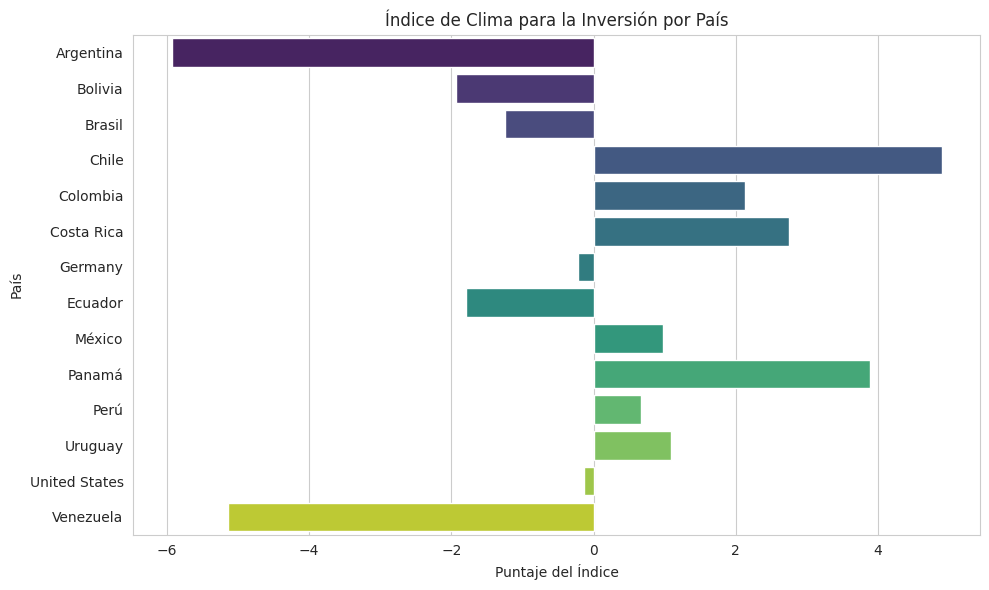

In [40]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_final,
    y='ShortName',
    x='Indice_Inversion',
    palette='viridis'
)

plt.title('Índice de Clima para la Inversión por País')
plt.xlabel('Puntaje del Índice')
plt.ylabel('País')
plt.tight_layout()
plt.show()

7.4. Analiza los resultados del gráfico y redacta una conclusiones para el MinCIT sobre el clima de inversión en la región, quiénes son nuestros competidores en la atracción de capitales extranjeros y por qué, en qué son mejores que Colombia.

**Conclusiones.**

El índice de clima para la inversión, construido a partir del Análisis de Componentes Principales, evidencia diferencias marcadas entre los países de la región. Chile y Panamá destacan como los destinos más atractivos para la inversión extranjera. Les siguen Costa Rica y Colombia, que también muestran desempeños favorables, aunque en menor medida. En contraste, países como Argentina, Venezuela y Bolivia se ubican en el extremo inferior, con puntajes fuertemente negativos que reflejan problemas como inestabilidad macroeconómica, alta inflación, elevados niveles de endeudamiento y debilidad institucional.

En términos de competencia directa por la atracción de capital extranjero, los principales rivales de Colombia son Chile, Panamá y Costa Rica. Chile sobresale por su alta apertura comercial, solidez macroeconómica, baja inflación histórica y un marco institucional y regulatorio particularmente estable, lo que se traduce en mayores facilidades para hacer negocios y una mayor seguridad jurídica para los inversionistas. Por su parte, Panamá capitaliza su rol como hub logístico y financiero regional, respaldado por un alto dinamismo en el comercio internacional, un sistema dolarizado que elimina el riesgo cambiario y una infraestructura diseñada para facilitar la actividad empresarial. Costa Rica, aunque cuenta con una economía más pequeña, ha logrado posicionarse como un destino atractivo gracias a su estabilidad política, la inversión sostenida en educación y salud, y su integración en cadenas de valor de manufactura avanzada y servicios, lo que incluso se refleja en su fuerte captación de inversión extranjera en la región .

En este contexto, Colombia ocupa una posición competitiva dentro de la región, lo cual resulta positivo. Sin embargo, la brecha frente a los países líderes sugiere que aún persisten desafíos importantes, especialmente en materia de institucionalidad, eficiencia regulatoria y estabilidad macroeconómica. De hecho, el país todavía enfrenta barreras relativamente altas para la inversión extranjera en comparación con otros mercados . Reducir estas limitaciones debería ser una prioridad en la agenda de política pública orientada a fortalecer la atracción de inversión extranjera directa por parte del MinCIT.